<a href="https://colab.research.google.com/github/reshma-susarapu/Python_assessment/blob/main/Bronze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

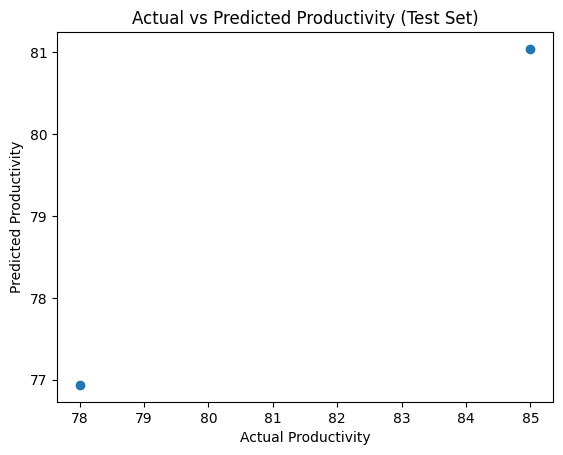

Mean Squared Error: 8.396082170603862
R² Score: 0.3146055370935623


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
data = {
    'Experience': [2,5,1,8,4,10,3,6,7,2],
    'TrainingHours': [40,60,20,80,50,90,30,70,75,25],
    'WorkingHours': [38,42,35,45,40,48,37,44,46,36],
    'Projects': [3,6,2,8,5,9,4,7,7,3],
    'Productivity': [62,78,55,88,72,92,65,82,85,60]
}

df = pd.DataFrame(data)
x = df[['Experience', 'TrainingHours', 'WorkingHours', 'Projects']]#independent variables
y = df['Productivity']#dependent variable
#spliting the data into train and test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(x_train, y_train)#learning from the features
y_pred = model.predict(x_test)#applying to the test data
plt.figure()
plt.scatter(y_test, y_pred)
#plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.plot()
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs Predicted Productivity (Test Set)")
plt.show()
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R² Score:", r2)

In [ ]:
#Which factor most strongly impacts productivity?
#How does training affect productivity?
#Should the company increase training hours or working hours?
#What happens if Working Hours increase beyond optimal limits?
#Can productivity ever decrease with more experience?
#How would you detect overfitting in this model?
#Suggest one new feature to improve prediction accuracy.

In [ ]:
print("Model Coefficients:")
coefficients = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_})
print(coefficients.sort_values(by='Coefficient', ascending=False))

Model Coefficients:
         Feature  Coefficient
3       Projects     4.885986
1  TrainingHours     0.272684
0     Experience    -0.263658
2   WorkingHours    -1.085511


**2nd code**

Problem 2 - Credit Card Fraud Detection

A bank wants to detect fraudulent transactions in real time.
Each transaction must be classified as:

0 → Legitimate  

1 → Fraud

Data Set

TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
1,1200,2,1,500,1,1,0,1
2,50,24,0,200,0,0,1,0
3,5000,1,1,450,1,1,0,1
4,200,48,0,300,0,0,1,0
5,1500,3,1,700,1,0,0,1
6,75,72,0,150,0,0,1,0
7,3200,2,1,400,1,1,0,1
8,40,96,0,100,0,0,1,0
9,2100,5,1,600,1,1,0,1
10,60,120,0,120,0,0,1,0

Feature Explanation

Amount → Transaction amount  

TimeSinceLastTxn → Hours since last transaction  

LocationChange → 1 if location differs from previous  

AvgTxnAmount → User’s average spending  

IsForeignTransaction → International transaction  

IsHighRiskCountry → Risky country flag  

CardPresent → Physical card used (0 = online, 1 = swipe)  

IsFraud → Target variable



Interpretation  

Write the logistic regression equation for this dataset.  

How do you interpret model coefficients (e.g., for Amount)?  

What happens if two features are highly correlated?  

Train a logistic regression model on this dataset  

Plot ROC curve  

Tune threshold (not just 0.5)  

Add regularization (L1/L2) and compare results



Original Dataset:

   TransactionID  Amount  TimeSinceLastTxn  LocationChange  AvgTxnAmount  \
0              1    1200                 2               1           500   
1              2      50                24               0           200   
2              3    5000                 1               1           450   
3              4     200                48               0           300   
4              5    1500                 3               1           700   
5              6      75                72               0           150   
6              7    3200                 2               1           400   
7              8      40                96               0           100   
8              9    2100                 5               1           600   
9             10      60               120               0           120   

   IsForeignTransaction  IsHighRiskCountry  CardPresent  IsFraud  
0                     1                  1            0        1  
1         

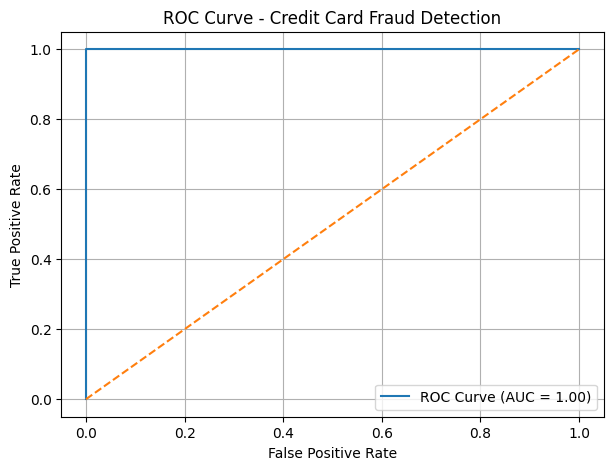


-----------------------------
THRESHOLD TUNING
-----------------------------

Threshold = 0.3
Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]

Threshold = 0.4
Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]

Threshold = 0.5
Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]

Threshold = 0.6
Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]

Threshold = 0.7
Accuracy: 1.0
Confusion Matrix:
 [[1 0]
 [0 1]]

Best Threshold (Youden's J): 0.9507129435065239

Confusion Matrix at Best Threshold:
 [[1 0]
 [0 1]]

Classification Report at Best Threshold:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


-----------------------------
L2 REGULARIZATION RESULTS
-----------------------------
Accuracy: 1.0
AUC: 1.0

L2 Coefficient

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)

data = pd.DataFrame({
    "TransactionID": [1,2,3,4,5,6,7,8,9,10],
    "Amount": [1200,50,5000,200,1500,75,3200,40,2100,60],
    "TimeSinceLastTxn": [2,24,1,48,3,72,2,96,5,120],
    "LocationChange": [1,0,1,0,1,0,1,0,1,0],
    "AvgTxnAmount": [500,200,450,300,700,150,400,100,600,120],
    "IsForeignTransaction": [1,0,1,0,1,0,1,0,1,0],
    "IsHighRiskCountry": [1,0,1,0,0,0,1,0,1,0],
    "CardPresent": [0,1,0,1,0,1,0,1,0,1],
    "IsFraud": [1,0,1,0,1,0,1,0,1,0]
})
print("Original Dataset:\n")
print(data)

print(data.isnull().sum())

data = data.drop(columns=["TransactionID"])

x = data.drop(columns=["IsFraud"])
y = data["IsFraud"]


print("FEATURES (X)")
print(x)

print("TARGET (y)")
print(y)

print(data.dtypes)



x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", x_train.shape)
print("X_test shape :", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)



scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)
print(x_train_scaled)
print(x_test_scaled)

model = LogisticRegression(max_iter=1000)
model.fit(x_train_scaled, y_train)


y_prob = model.predict_proba(x_test_scaled)[:, 1]   # Fraud probability
y_pred = (y_prob >= 0.5).astype(int)                # Default threshold = 0.5

print("\n-----------------------------")
print("MODEL EVALUATION")
print("-----------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Logistic Regression Equation
intercept = model.intercept_[0]
coefficients = model.coef_[0]
feature_names = x.columns

print("\n-----------------------------")
print("LOGISTIC REGRESSION EQUATION")
print("-----------------------------")

equation = f"z = {intercept:.4f}"
for feature, coef in zip(feature_names, coefficients):
    equation += f" + ({coef:.4f} * {feature})"

print(equation)
print("\nP(Fraud=1) = 1 / (1 + e^(-z))")

print("\nCoefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

# ---------------------------------------------
# 9. ROC Curve
# ---------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------
# 10. Threshold Tuning
# ---------------------------------------------
print("\n-----------------------------")
print("THRESHOLD TUNING")
print("-----------------------------")

thresholds_to_try = [0.3, 0.4, 0.5, 0.6, 0.7]

for th in thresholds_to_try:
    y_pred_th = (y_prob >= th).astype(int)
    acc = accuracy_score(y_test, y_pred_th)
    cm = confusion_matrix(y_test, y_pred_th)

    print(f"\nThreshold = {th}")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)

# ---------------------------------------------
# 11. Best Threshold using Youden's J Statistic
# ---------------------------------------------
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print("\nBest Threshold (Youden's J):", best_threshold)

y_pred_best = (y_prob >= best_threshold).astype(int)

print("\nConfusion Matrix at Best Threshold:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report at Best Threshold:\n", classification_report(y_test, y_pred_best))

# ---------------------------------------------
# 12. L2 Regularization
# ---------------------------------------------
model_l2 = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    C=1.0,
    max_iter=1000
)
model_l2.fit(x_train_scaled, y_train)
y_prob_l2 = model_l2.predict_proba(x_test_scaled)[:, 1]
y_pred_l2 = (y_prob_l2 >= 0.5).astype(int)

print("\n-----------------------------")
print("L2 REGULARIZATION RESULTS")
print("-----------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_l2))
print("AUC:", roc_auc_score(y_test, y_prob_l2))

print("\nL2 Coefficients:")
for feature, coef in zip(x.columns, model_l2.coef_[0]):
    print(f"{feature}: {coef:.4f}")

# ---------------------------------------------
# 13. L1 Regularization
# ---------------------------------------------
model_l1 = LogisticRegression(
    penalty="l1",
    solver="liblinear",#find the model parameter(weight) that minimize the loss and maximize the likelihood
    C=1.0,#how much you allow to fit the data
    max_iter=1000
)
model_l1.fit(x_train_scaled, y_train)

y_prob_l1 = model_l1.predict_proba(x_test_scaled)[:, 1]
y_pred_l1 = (y_prob_l1 >= 0.5).astype(int)

print("\n-----------------------------")
print("L1 REGULARIZATION RESULTS")
print("-----------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_l1))
print("AUC:", roc_auc_score(y_test, y_prob_l1))

print("\nL1 Coefficients:")
for feature, coef in zip(x.columns, model_l1.coef_[0]):
    print(f"{feature}: {coef:.4f}")

# ---------------------------------------------
# 14. Compare L1 vs L2
# ---------------------------------------------
print("\n-----------------------------")
print("L1 vs L2 COMPARISON")
print("-----------------------------")
print("L2 Accuracy:", accuracy_score(y_test, y_pred_l2))
print("L2 AUC     :", roc_auc_score(y_test, y_prob_l2))

print("\nL1 Accuracy:", accuracy_score(y_test, y_pred_l1))
print("L1 AUC     :", roc_auc_score(y_test, y_prob_l1))

# ---------------------------------------------
# 15. Correlation Matrix (Check Multicollinearity)
# ---------------------------------------------
print("\n-----------------------------")
print("CORRELATION MATRIX")
print("-----------------------------")
print(x.corr())


**Clustering**



Dataset Head:
    CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
1           2   25         18000             81               6            500
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
4           5   23         20000             77               5            450

-----------------
Summary Statistics
-----------------
       CustomerID        Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
count    10.00000  10.000000     10.000000      10.000000        10.00000   
mean      5.50000  37.000000  44000.000000      42.300000         3.80000   
std       3.02765  13.266499  23518.314376      28.488009         1.75119   
min       1.00000  22.000000  15000.000000       6.000000         1.00000   
25%       3.25000  25.750000  22500.000000      16.250000         2.2

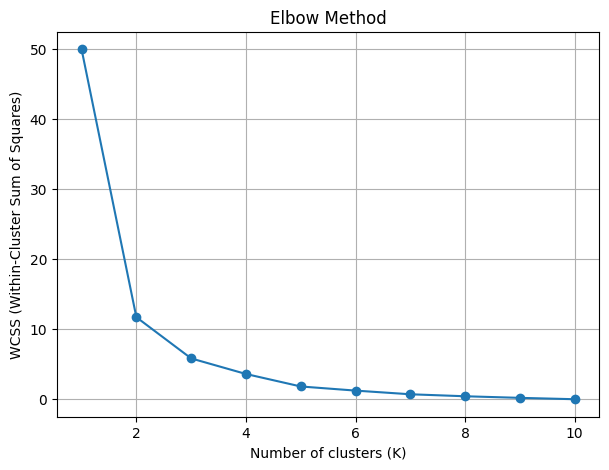

K=2, Silhouette Score=0.6073
K=3, Silhouette Score=0.5203
K=4, Silhouette Score=0.5134
K=5, Silhouette Score=0.4187
K=6, Silhouette Score=0.3034
K=7, Silhouette Score=0.2244
K=8, Silhouette Score=0.1736
K=9, Silhouette Score=0.0663


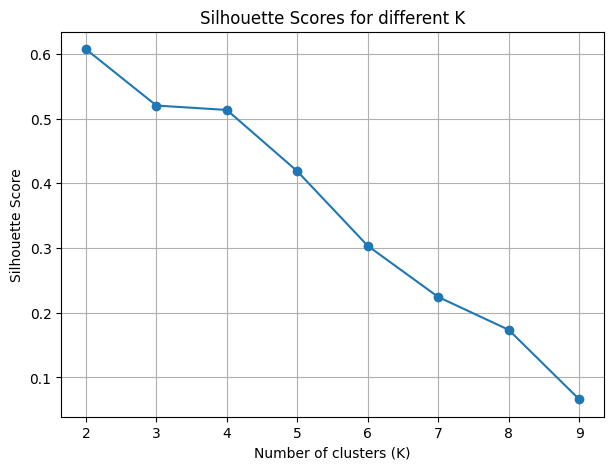


Cluster Labels:
    CustomerID  Cluster
0           1        2
1           2        1
2           3        0
3           4        0
4           5        1
5           6        0
6           7        2
7           8        2
8           9        0
9          10        1

Cluster Centroids (Original Scale):
          Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue  \
0  51.000000  68750.000000          12.75        2.000000     157.500000   
1  25.333333  22666.666667          76.00        5.666667     450.000000   
2  30.000000  32333.333333          48.00        4.333333     273.333333   

   Cluster  
0        0  
1        1  
2        2  


In [ ]:
# ---------------------------------------------
# Customer Segmentation using K-Means
# ---------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---------------------------------------------
# 1. Load Dataset
# ---------------------------------------------
data = pd.DataFrame({
    "CustomerID": [1,2,3,4,5,6,7,8,9,10],
    "Age": [22,25,47,52,23,45,33,35,60,28],
    "AnnualIncome": [15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
    "SpendingScore": [39,81,6,20,77,15,50,55,10,70],
    "VisitsPerMonth": [4,6,2,3,5,2,4,5,1,6],
    "AvgOrderValue": [200,500,150,200,450,180,300,320,100,400]
})

print("\nDataset Head:\n", data.head())

print("\n-----------------")
print("Summary Statistics")
print("-----------------")
print(data.describe())

print("\n-----------------")
print("Check for Missing Values")
print("-----------------")
print(data.isnull().sum())

X = data.drop(columns=["CustomerID"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Features:\n", X_scaled)

# ---------------------------------------------
# 5. Elbow Method to find optimal K
# ---------------------------------------------
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

# ---------------------------------------------
# 6. Silhouette Scores
# ---------------------------------------------
sil_scores = []

# The valid range for k is 2 to n_samples - 1. Here n_samples is 10, so k goes up to 9.
for k in range(2, len(X_scaled)):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(7,5))
plt.plot(range(2, len(X_scaled)), sil_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for different K")
plt.grid(True)
plt.show()

# ---------------------------------------------
# 7. Apply K-Means with chosen K
# Based on Elbow and Silhouette, choose K (e.g., 3)
# ---------------------------------------------
optimal_k = 3 # Choose an optimal k based on the plots (e.g., 3 in this case)
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to original dataset
data['Cluster'] = cluster_labels

print("\nCluster Labels:\n", data[['CustomerID','Cluster']])

# ---------------------------------------------
# 8. Cluster Centroids
# ---------------------------------------------
centroids = kmeans_final.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids)  # optional: back to original scale

centroids_df = pd.DataFrame(centroids_unscaled, columns=X.columns)
centroids_df['Cluster'] = range(optimal_k)

print("\nCluster Centroids (Original Scale):\n", centroids_df)
